In [79]:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Setup complete ✓")

Setup complete ✓


In [80]:
df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean():.4%}")

Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


In [81]:
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} transactions ({y_train.sum()} frauds)")
print(f"Test set:     {X_test.shape[0]:,} transactions ({y_test.sum()} frauds)")

Training set: 227,845 transactions (394 frauds)
Test set:     56,962 transactions (98 frauds)


In [82]:
naive_predictions = np.zeros(len(y_test))  # All zeros = "not fraud"
naive_accuracy = (naive_predictions == y_test).mean()

print(f"Naïve baseline accuracy: {naive_accuracy:.4%}")
print(f"Naïve baseline recall (fraud class): {recall_score(y_test, naive_predictions):.4%}")
print(f"\n→ 99.83% accuracy, 0% recall. The accuracy paradox in action.")

Naïve baseline accuracy: 99.8280%
Naïve baseline recall (fraud class): 0.0000%

→ 99.83% accuracy, 0% recall. The accuracy paradox in action.


In [83]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_prob = log_reg.predict_proba(X_test)[:, 1]  
y_pred = log_reg.predict(X_test)  

print(f"Model accuracy: {(y_pred == y_test).mean():.4%}")

Model accuracy: 99.9157%


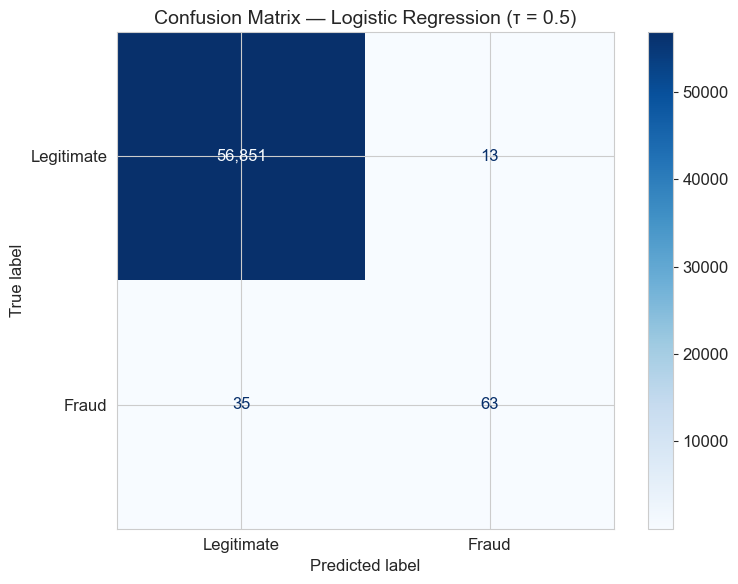

True Positives (fraud caught):     63
False Negatives (fraud missed):     35
False Positives (legit blocked):    13
True Negatives (legit approved):    56,851


In [84]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (fraud caught):     {tp}")
print(f"False Negatives (fraud missed):     {fn}")
print(f"False Positives (legit blocked):    {fp}")
print(f"True Negatives (legit approved):    {tn:,}")

In [85]:
print("Classification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print("\n→ Focus on the FRAUD row. That's the class that matters.")
print("→ 'macro avg' = unweighted mean across classes.")
print("→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).")

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


→ Focus on the FRAUD row. That's the class that matters.
→ 'macro avg' = unweighted mean across classes.
→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).


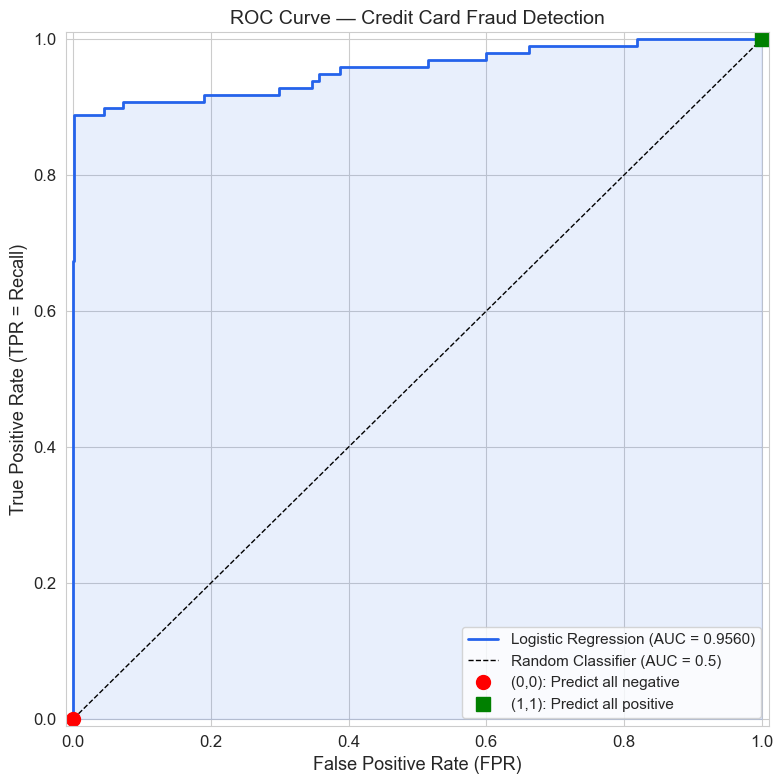

AUC = 0.9560

Interpretation: There is a 95.6% probability that the model
ranks a random fraud transaction higher than a random legitimate transaction.


In [86]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')

ax.plot(0, 0, 'ro', markersize=10, label='(0,0): Predict all negative')
ax.plot(1, 1, 'gs', markersize=10, label='(1,1): Predict all positive')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax.set_title('ROC Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"AUC = {auc_score:.4f}")
print(f"\nInterpretation: There is a {auc_score:.1%} probability that the model")
print(f"ranks a random fraud transaction higher than a random legitimate transaction.")

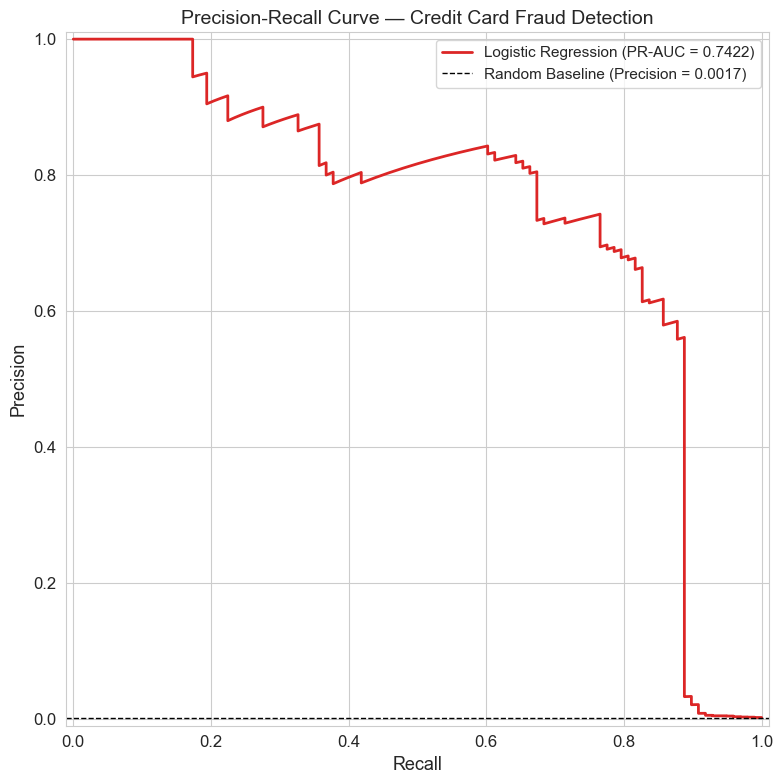

PR-AUC = 0.7422


In [87]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')

baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random Baseline (Precision = {baseline:.4f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"PR-AUC = {pr_auc:.4f}")

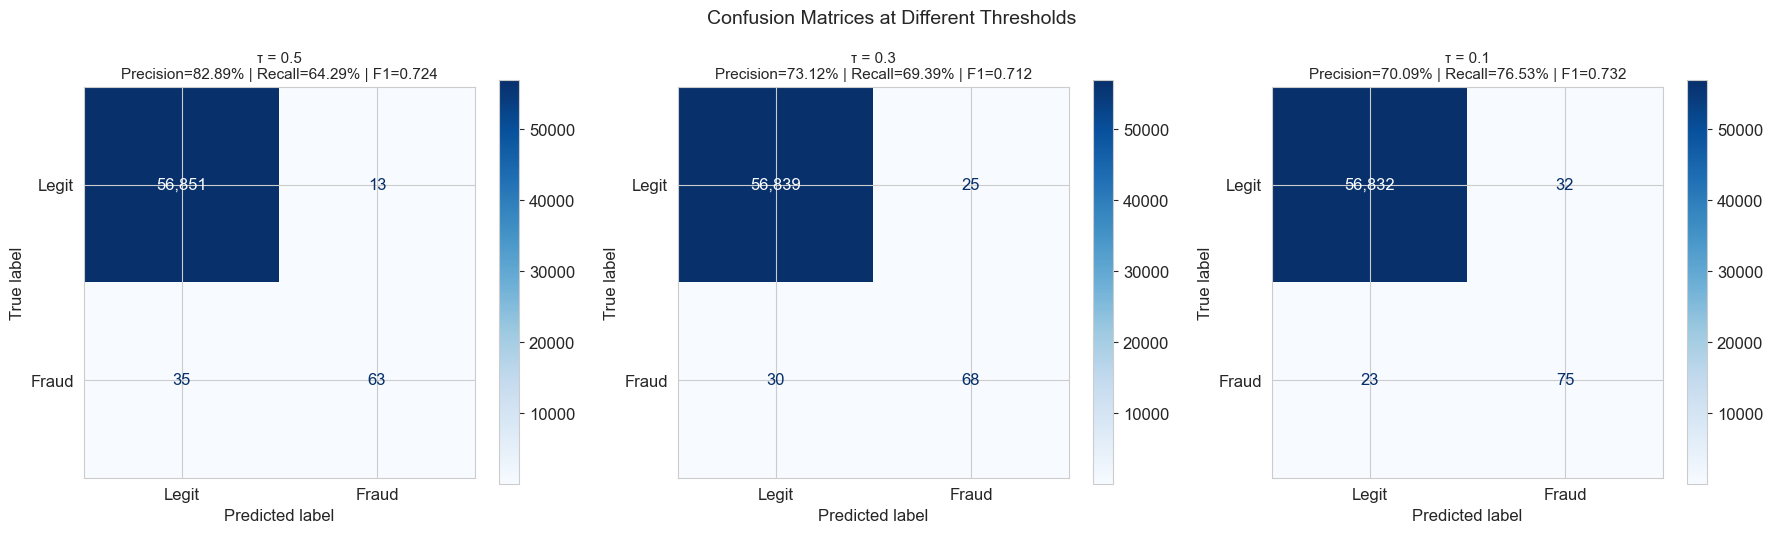

In [88]:
thresholds_to_test = [0.5, 0.3, 0.1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, tau in enumerate(thresholds_to_test):
    y_pred_tau = (y_prob >= tau).astype(int)
    cm_tau = confusion_matrix(y_test, y_pred_tau)

    prec = precision_score(y_test, y_pred_tau, zero_division=0)
    rec = recall_score(y_test, y_pred_tau)
    f1 = f1_score(y_test, y_pred_tau)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_tau, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', values_format=',')
    axes[i].set_title(f'τ = {tau}\nPrecision={prec:.2%} | Recall={rec:.2%} | F1={f1:.3f}',
                      fontsize=11)

plt.suptitle('Confusion Matrices at Different Thresholds', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

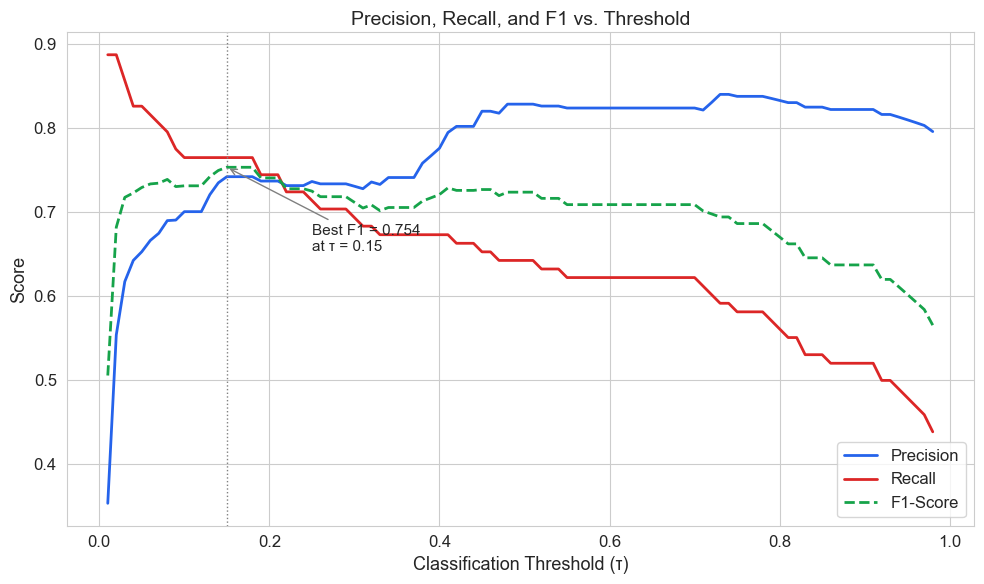


Optimal threshold for F1: τ = 0.15 (F1 = 0.754)


In [89]:
f1_scores = []
precision_scores = []
recall_scores = []
threshold_range = np.arange(0.01, 0.99, 0.01)

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_tau, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_tau, zero_division=0))

# Plot metrics vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, recall_scores, label='Recall', color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores, label='F1-Score', color='#16a34a', linewidth=2, linestyle='--')

best_tau = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
ax.axvline(x=best_tau, color='gray', linestyle=':', linewidth=1)
ax.annotate(f'Best F1 = {best_f1:.3f}\nat τ = {best_tau:.2f}',
            xy=(best_tau, best_f1), xytext=(best_tau + 0.1, best_f1 - 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold for F1: τ = {best_tau:.2f} (F1 = {best_f1:.3f})")

In [90]:
max_investigations = 500

for tau in np.arange(0.01, 0.99, 0.01):
    n_flagged = (y_prob >= tau).sum()
    if n_flagged <= max_investigations:
        y_pred_capacity = (y_prob >= tau).astype(int)
        rec = recall_score(y_test, y_pred_capacity)
        prec = precision_score(y_test, y_pred_capacity, zero_division=0)
        print(f"τ = {tau:.2f} → {n_flagged} flagged | Recall = {rec:.2%} | Precision = {prec:.2%}")
        break

# While having a 88.78% recall is good for catching most fraud, having a 35.37% accuracy is very low

τ = 0.01 → 246 flagged | Recall = 88.78% | Precision = 35.37%


2026-04-17 00:50:14.807 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:50:14.808 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-17 00:50:14.808 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-17 00:50:14.809 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:50:14.839 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:50:15.883 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-17 00:50:15.884 WARNING streamlit.runtime.cachi

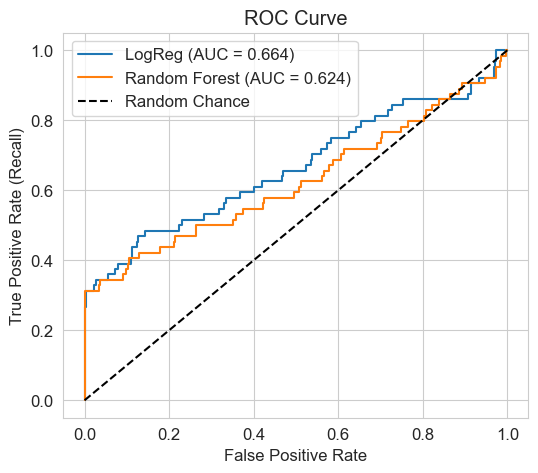

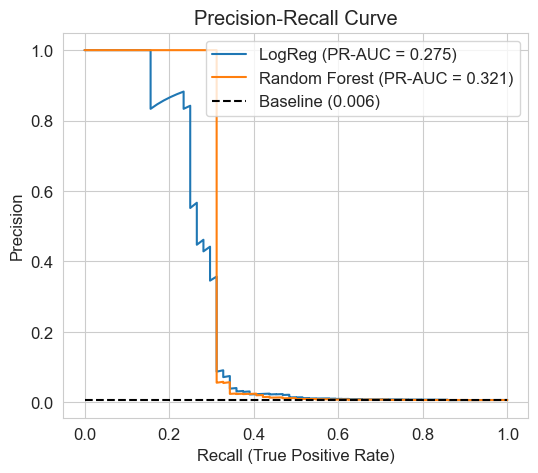

In [91]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             precision_recall_curve, auc, precision_score,
                             recall_score, f1_score)

# Set page to wide mode for better dashboard viewing
st.set_page_config(page_title="Fraud Detection Dashboard", layout="wide")

# --- 1. DATA & MODEL CACHING ---

@st.cache_data
def load_data():
    """
    Replace this block with your Kaggle dataset loading logic.
    For demonstration, we generate highly imbalanced synthetic data mirroring the Kaggle set.
    """
    X, y = make_classification(n_samples=50000, n_features=20, n_classes=2, 
                               weights=[0.998, 0.002], random_state=42)
    
    # Simulating your train/test split
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    return X_train, X_test, y_train, y_test

@st.cache_resource
def train_models(X_train, y_train):
    """
    Train and cache both models. 
    @st.cache_resource is used here instead of cache_data because ML models 
    are complex objects/resources, not simple dataframes.
    """
    # Your existing Logistic Regression
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train, y_train)
    
    # The requested Random Forest comparison
    rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf_clf.fit(X_train, y_train)
    
    return log_reg, rf_clf

# Load data and models
X_train, X_test, y_train, y_test = load_data()
log_reg, rf_clf = train_models(X_train, y_train)

# Pre-compute probabilities for the test set
# We cache these too, so the slider only performs simple array slicing/comparisons
@st.cache_data
def get_probabilities(X_test):
    y_prob_log = log_reg.predict_proba(X_test)[:, 1]
    y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]
    return y_prob_log, y_prob_rf

y_prob_log, y_prob_rf = get_probabilities(X_test)


# --- 2. DASHBOARD UI & INTERACTIVITY ---

st.title("Fraud Detection Evaluation Dashboard")

# --- Mechanism Check: Streamlit Reruns ---
# HOW st.slider WORKS: Every time the user moves this slider, Streamlit halts execution, 
# updates the `threshold` variable in memory, and re-runs this entire Python script from top to bottom.
# Because our data loading and model training are wrapped in @st.cache_*, Streamlit skips 
# those expensive steps and only recalculates the fast operations below.
st.sidebar.header("Operating Controls")
threshold = st.sidebar.slider("Decision Threshold ($\tau$)", min_value=0.00, max_value=1.00, value=0.50, step=0.01)

st.sidebar.markdown("---")
st.sidebar.header("Cost Assumptions")
cost_fp = st.sidebar.number_input("Cost of False Positive ($)", value=10) # e.g., manual investigation cost
cost_fn = st.sidebar.number_input("Cost of False Negative ($)", value=500) # e.g., average fraud chargeback

# Generate predictions based on the dynamic threshold
y_pred_log = (y_prob_log >= threshold).astype(int)

# Calculate metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_log).ravel()
prec = precision_score(y_test, y_pred_log, zero_division=0)
rec = recall_score(y_test, y_pred_log, zero_division=0)
f1 = f1_score(y_test, y_pred_log, zero_division=0)

# --- Mechanism Check: Cost Metric Calculation ---
# FN * cost_fn: Every time we miss fraud (False Negative), we lose the transaction amount (e.g., $500).
# FP * cost_fp: Every time we falsely flag a good user (False Positive), we pay an ops cost to review it (e.g., $10).
# This creates a tangible business metric rather than just an abstract statistical one.
total_cost = (fn * cost_fn) + (fp * cost_fp)

# Display Top-Level Metrics
col1, col2, col3, col4 = st.columns(4)
col1.metric("Precision", f"{prec:.2%}")
col2.metric("Recall", f"{rec:.2%}")
col3.metric("F1 Score", f"{f1:.4f}")
col4.metric("Total Operational Cost", f"${total_cost:,.2f}")

st.markdown("---")

# --- 3. CONFUSION MATRIX ---
st.subheader(f"Logistic Regression Performance at Threshold = {threshold}")
st.write(f"**Confusion Matrix:** TN={tn} | FP={fp} | FN={fn} | TP={tp}")

# --- 4. MODEL COMPARISON (ROC vs PR) ---
st.header("Model Comparison: Logistic Regression vs. Random Forest")

col_roc, col_pr = st.columns(2)

# --- ROC Curve Panel ---
with col_roc:
    fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
    
    fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
    
    auc_log = roc_auc_score(y_test, y_prob_log)
    auc_rf = roc_auc_score(y_test, y_prob_rf)
    
    ax_roc.plot(fpr_log, tpr_log, label=f'LogReg (AUC = {auc_log:.3f})')
    ax_roc.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate (Recall)')
    ax_roc.set_title('ROC Curve')
    ax_roc.legend()
    st.pyplot(fig_roc)

# --- PR Curve Panel ---
# --- Mechanism Check: PR-AUC vs ROC-AUC for Imbalanced Data ---
# ROC-AUC measures True Positive Rate against False Positive Rate. Because FPR is calculated as 
# FP / (FP + TN), a massive number of True Negatives (legitimate transactions) drags the FPR down 
# to near zero, making the ROC curve look overly optimistic.
# PR-AUC measures Precision vs Recall. Precision is TP / (TP + FP). It completely ignores True 
# Negatives. This forces the metric to focus entirely on the minority class (fraud), making it a 
# much stricter and more informative metric for highly imbalanced datasets.
with col_pr:
    fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
    
    prec_log, recall_log, _ = precision_recall_curve(y_test, y_prob_log)
    prec_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
    
    pr_auc_log = auc(recall_log, prec_log)
    pr_auc_rf = auc(recall_rf, prec_rf)
    
    ax_pr.plot(recall_log, prec_log, label=f'LogReg (PR-AUC = {pr_auc_log:.3f})')
    ax_pr.plot(recall_rf, prec_rf, label=f'Random Forest (PR-AUC = {pr_auc_rf:.3f})')
    
    # Baseline for PR curve is the ratio of positives to total
    baseline = sum(y_test) / len(y_test)
    ax_pr.plot([0, 1], [baseline, baseline], 'k--', label=f'Baseline ({baseline:.3f})')
    
    ax_pr.set_xlabel('Recall (True Positive Rate)')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title('Precision-Recall Curve')
    ax_pr.legend()
    st.pyplot(fig_pr)